# Data Vis: Visualizing Numerical and Categorical Data
* Notebook 1: Visualizing Proportions

## Setup

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import squarify
import seaborn as sns

## Data

In this notebook, we will use the NYC Flights 2013 dataset, which contains information about all domestic flights that departed from NYC in 2013. The dataset includes the following tables:
- `flights`: Contains information about each flight, including the origin and destination airports, departure and arrival times, and delays.
- `planes`: Contains information about the planes, including their tail numbers and model years.
- `airports`: Contains information about the airports, including their names and locations.
- `airlines`: Contains information about the airlines, including their names and IATA codes.
- `weather`: Contains information about the weather at the origin airports, including temperature, wind speed, and precipitation.

In [2]:
data = pd.read_csv('flights_joined.csv')

In [3]:
data.shape

(336776, 53)

In [4]:
data.head()

,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,...,tzone_dest,temp,dewp,humid,wind_dir,wind_speed,wind_gust,precip,pressure,visib
0,2013,1,1,517.0,515,2.0,830.0,819,11.0,UA,...,America/Chicago,39.02,28.04,64.43,260.0,12.65858,NaN,0.0,1011.9,10.0
1,2013,1,1,533.0,529,4.0,850.0,830,20.0,UA,...,America/Chicago,39.92,24.98,54.81,250.0,14.96014,21.86482,0.0,1011.4,10.0
2,2013,1,1,542.0,540,2.0,923.0,850,33.0,AA,...,America/New_York,39.02,26.96,61.63,260.0,14.96014,NaN,0.0,1012.1,10.0
3,2013,1,1,544.0,545,-1.0,1004.0,1022,-18.0,B6,...,NaN,39.02,26.96,61.63,260.0,14.96014,NaN,0.0,1012.1,10.0
4,2013,1,1,554.0,600,-6.0,812.0,837,-25.0,DL,...,America/New_York,39.92,24.98,54.81,260.0,16.11092,23.01560,0.0,1011.7,10.0


## Treemap

A treemap is a fancy way to visualize proportions. It is a hierarchical visualization that uses (nested) rectangles to represent the proportions of different categories within a dataset. The size of each rectangle is proportional to the value it represents, and the color can be used to represent another variable. Unfortunately, seaborn does not have a built-in treemap function, but we can use the `squarify` library to create one (it uses `matplotlib` in the background). 

But before we can create a treemap, we need to aggregate the data (in this case by `origin`).

In [5]:
data_grouped = data.groupby('origin').size().reset_index(name='num_flights')
data_grouped.head()

,origin,num_flights
0,EWR,120835
1,JFK,111279
2,LGA,104662


Now we can use the `squarify` library to create a treemap. The `squarify` library requires the following parameters:
- `sizes`: A list of the sizes of each rectangle (in this case, the number of flights from each origin).
- `label`: A list of the labels for each rectangle (in this case, the origin airport codes).
- `color`: A list of colors for each rectangle (in this case, the number of origin airports).

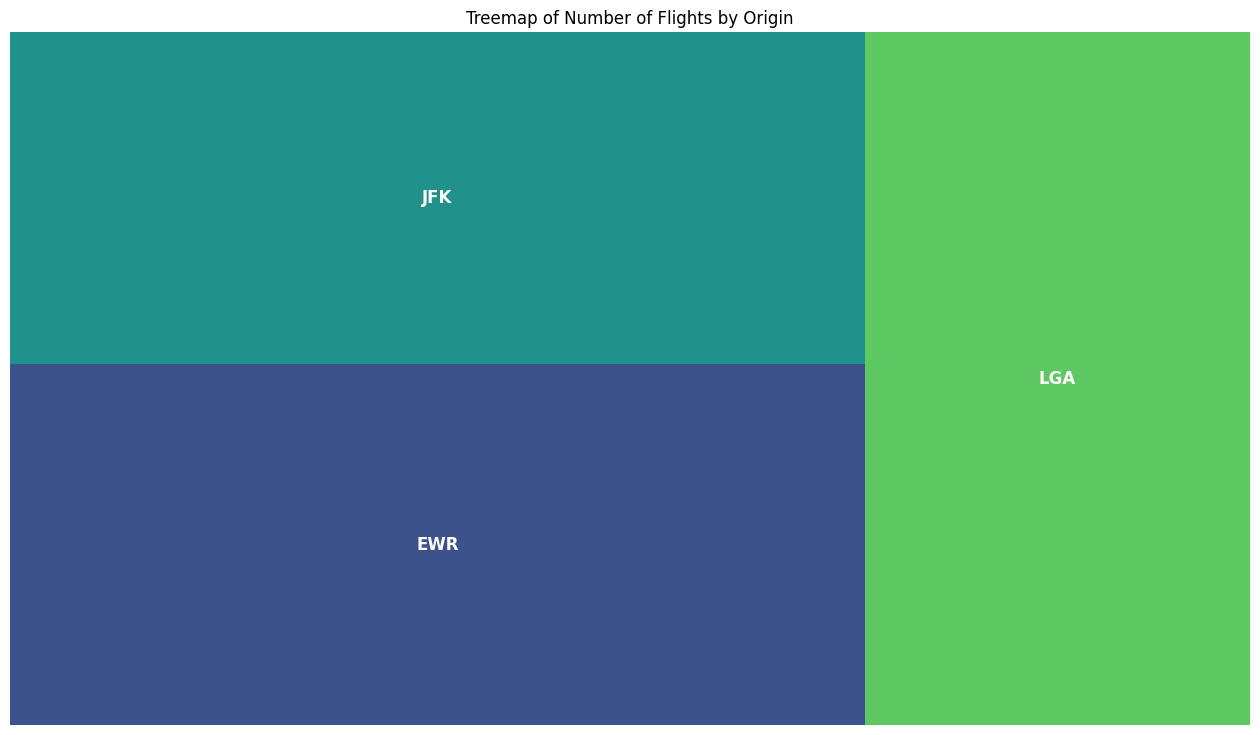

In [13]:
plt.figure(figsize=(16, 9))
squarify.plot(sizes=data_grouped['num_flights'], label=data_grouped['origin'],
  color=sns.color_palette('viridis', n_colors=len(data_grouped['origin'])),
  text_kwargs={'color': 'white', 'fontweight': 'bold', 'fontsize':12})
plt.axis('off')
plt.title('Treemap of Number of Flights by Origin')
plt.show()


`squarify` does not support nested treemaps. Have a look at `plotly` for a more advanced interactive treemap visualizations: https://plotly.com/python/treemaps/

Now it's your turn. Create a heatmap of different part-whole relationship in the dataset...

In [ ]:
# YOUR CODE HERE